In [45]:
import numpy as np
from netCDF4 import Dataset
import xroms
import roppy
import xarray as xr
from typing import Sequence
from latlon import ll2xy #separate python script
from interpolator import interpolator #separate python script
from create_adsenfile import create_adsenfile #separate python script
import matplotlib.pyplot as plt
import cmocean
import subprocess
from scipy import integrate
import warnings
warnings.filterwarnings("ignore")

## About this notebook

We go through the process of creating a forcing file for use in ROMS impact simulations. The chosen metric for assessing impact is the potential energy anomaly (PEA), which serves as an indicator of stratification strength.

## PEA example - what is it?

In [21]:
def diff2(X: np.ndarray) -> np.ndarray:
    """Central differences of a sequence"""
    n = len(X)
    Y = np.empty(n + 2, dtype=X.dtype)
    Y[1:-1] = X
    Y[0] = X[0]
    Y[-1] = X[-1]
    return Y[2:] - Y[:-2]

In [27]:
fwdfile = 'https://thredds.met.no/thredds/dodsC/foccus/norshelf-ana_fwd_20250501T00Z_outer0.nc'
Inp = xroms.open_netcdf(fwdfile, chunks={"ocean_time": 1}, Vtransform=2)
Inp, grid = xroms.roms_dataset(Inp, add_verts=False, include_Z0=True, Vtransform=2)
mask = Inp.mask_rho.values

In [23]:
latSvinoy = np.array([62.367, 62.485, 62.602, 62.720, 62.780, 62.838, 62.897, 62.957, 63.073, 63.192, 63.310])#, 63.427, 63.663, 63.898, 64.135, 64.370])
lonSvinoy = np.array([5.2, 4.945, 4.690, 4.433, 4.305, 4.175, 4.047, 3.917, 3.657, 3.395, 3.133])#, 2.870, 2.338, 1.802, 1.262, 0.728])

x0, y0 = ll2xy(Inp, lonSvinoy[0], latSvinoy[0])
x1, y1 = ll2xy(Inp, lonSvinoy[-1], latSvinoy[-1])

Npoints = 30
X = np.linspace(x0, x1, Npoints)
Y = np.linspace(y0, y1, Npoints)

In [29]:
def section(A: xr.Dataset, X: Sequence[float], Y: Sequence[float]) -> xr.Dataset:
    """Slice a Dataset along a vertical section"""
    # Make temporary DataArrays for initial interpolations
    X0 = xr.DataArray(X, dims=["distance"])
    Y0 = xr.DataArray(Y, dims=["distance"])
    # Distance between section points
    pm = A.pm.interp(xi_rho=X0, eta_rho=Y0).values
    pn = A.pn.interp(xi_rho=X0, eta_rho=Y0).values
    dX = 2 * np.diff(X) / (pm[:-1] + pm[1:])
    dY = 2 * np.diff(Y) / (pn[:-1] + pn[1:])
    dS = np.sqrt(dX * dX + dY * dY)
    # Cumulative distance along the section
    distance = np.concatenate(([0], np.cumsum(dS))) / 1000.0  # unit = km
    X0["distance"] = distance
    Y0["distance"] = distance
    # Interpolate to the section making an intermediate Dataset
    B0 = A.interp(xi_rho=X0, eta_rho=Y0)

    # Initialize the proper section Dataset
    B = xr.Dataset(dict(xi_rho=X, eta_rho=Y, s_rho=A.s_rho))

    # Weights for trapezoidal integration
    V = 0.5 * (np.concatenate(([0], dS)) + np.concatenate((dS, [0])))
    B["dS"] = xr.DataArray(V, dims=["distance"], coords=dict(distance=B0["distance"].values))

    # Scalar data variables
    for var in ["h", "temp", "salt", "zeta", 'sig0', 'mld']:
        if var in B0:
            B[var] = B0[var]

    # Velocity
    if "u" in A:
        B["u"] = A.u.interp(xi_u=X0, eta_rho=Y0)
        B = B.drop(["xi_u"])
    if "v" in A:
        B["v"] = A.v.interp(xi_rho=X0, eta_v=Y0)
        B = B.drop(["eta_v"])
        
    # Normal velocity ++
    if "u" in A:
        dX = diff2(X)
        dY = diff2(Y)
        norm = np.sqrt(dX * dX + dY * dY)
        # Unit normal vector
        nX = -dY / norm
        nY = dX / norm
        B["u_norm"] = B["u"] * nX + B["v"] * nY

    # More vertical structure
    #B.coords["z_w0"] = B0.z_w0
    V = B0.z_w0.values[1:, :] - B0.z_w0.values[:-1, :]
    #B["dZ"] = xr.DataArray(V, dims=["s_rho", "distance"])
    print(V.shape)
    print(B["temp"].values.shape)
    print(B0["temp"].values.shape)
    #B["dZ"] = xr.DataArray(V, dims=["s_rho", "distance"], coords=dict(distance=B["distance"].values, s_rho=B["s_rho"].values))
    B["dZ"] = B["temp"]*5 
    B["dZ"].values[:] = V
    B["area"] = B.dZ * B.dS  # Unit = m**2

    return B

In [30]:
res = section(Inp.isel(ocean_time=0), X, Y)

(42, 30)
(42, 30)
(42, 30)


In [31]:
res

<xarray.Dataset>
Dimensions:     (xi_rho: 30, eta_rho: 30, s_rho: 42, distance: 30)
Coordinates: (12/17)
  * xi_rho      (xi_rho) float64 279.5 280.3 281.0 281.8 ... 299.8 300.5 301.3
  * eta_rho     (eta_rho) float64 214.7 216.7 218.6 220.6 ... 268.0 270.0 271.9
    ocean_time  datetime64[ns] 2025-04-29
  * s_rho       (s_rho) float64 -0.9881 -0.9643 -0.9405 ... -0.03571 -0.0119
  * distance    (distance) float64 0.0 5.103 10.21 15.31 ... 138.0 143.1 148.3
    lat_rho     (distance) float64 dask.array<chunksize=(30,), meta=np.ndarray>
    ...          ...
    z_rho_u     (s_rho, distance) float64 dask.array<chunksize=(42, 30), meta=np.ndarray>
    z_rho_u0    (s_rho, distance) float64 dask.array<chunksize=(42, 30), meta=np.ndarray>
    lat_v       (distance) float64 dask.array<chunksize=(30,), meta=np.ndarray>
    lon_v       (distance) float64 dask.array<chunksize=(30,), meta=np.ndarray>
    z_rho_v     (s_rho, distance) float64 dask.array<chunksize=(42, 30), meta=np.ndarray>
    z_rho_v0    (s_rho, distance) float64 dask.array<chunksize=(42, 30), meta=np.ndarray>
Data variables:
    dS          (distance) float64 2.551e+03 5.103e+03 ... 5.122e+03 2.561e+03
    h           (distance) float64 dask.array<chunksize=(30,), meta=np.ndarray>
    temp        (s_rho, distance) float32 dask.array<chunksize=(42, 30), meta=np.ndarray>
    salt        (s_rho, distance) float32 dask.array<chunksize=(42, 30), meta=np.ndarray>
    zeta        (distance) float32 dask.array<chunksize=(30,), meta=np.ndarray>
    u           (s_rho, distance) float32 dask.array<chunksize=(42, 30), meta=np.ndarray>
    v           (s_rho, distance) float32 dask.array<chunksize=(42, 30), meta=np.ndarray>
    u_norm      (s_rho, distance) float64 dask.array<chunksize=(42, 30), meta=np.ndarray>
    dZ          (s_rho, distance) float32 dask.array<chunksize=(42, 30), meta=np.ndarray>
    area        (s_rho, distance) float64 dask.array<chunksize=(42, 30), meta=np.ndarray>

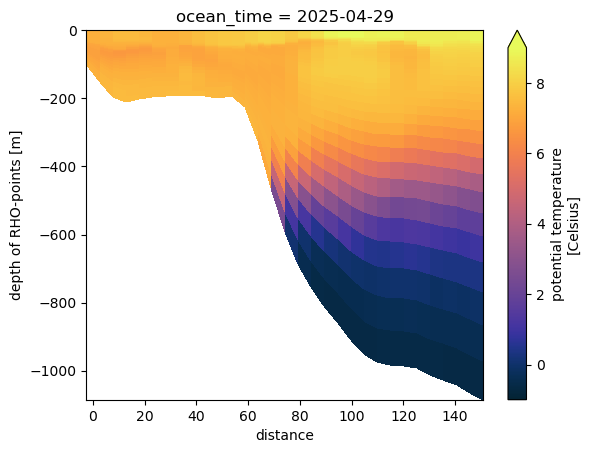

In [34]:
res.temp.plot(y='z_rho', vmin=-1, vmax=9, cmap=cmocean.cm.thermal, robust=True)

### Density in the upper part of the water column:

In [35]:
# Density: 
dens = xroms.potential_density(res.temp, res.salt, z=0) 

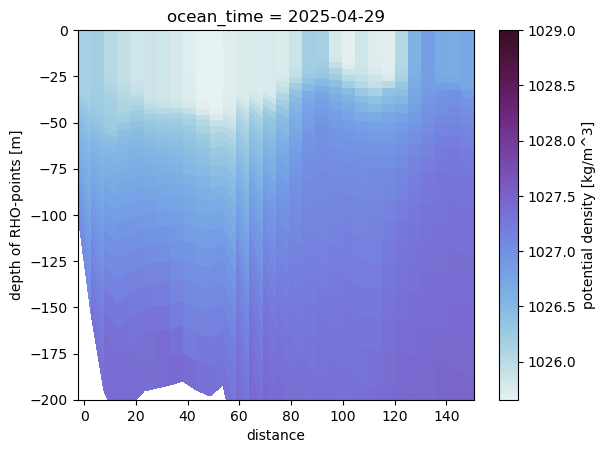

In [36]:
dens.plot(y='z_rho', ylim=[-200, 0], cmap=cmocean.cm.dense, vmax=1029)

### Calculate PEA:

In [37]:
def find_data_for_calculation(dssec, D):
    # z at rho points and potential density:
    z_rho = dssec.z_rho.values
    sig0s = dssec.values
    
    upper_values = np.zeros_like(sig0s)
    upper_depths = np.zeros_like(sig0s)
    
    for i, grid_point in enumerate(z_rho.reshape(-1, z_rho.shape[-1])):
        upper_ix = np.where(np.abs(grid_point) <= D)[0]
        if not upper_ix.size == 0: 
            upper_values[i, :] = np.nan
            upper_values[i, upper_ix] = sig0s[i, upper_ix]
            upper_depths[i, :] = np.nan
            upper_depths[i, upper_ix] = grid_point[upper_ix]
        else:
            upper_values[i, :] = np.nan
            upper_depths[i, :] = np.nan
            
    return upper_values, upper_depths

In [38]:
def calculate_mean_potrho(dssec, upper_values, upper_depths, D):
    z_rho = dssec.z_rho.values
    sig0s = dssec.values
    sig0mean = np.zeros_like(dssec.distance.values)
    for s in range(0, len(dssec.distance.values)):
        interp_bottom = np.interp(-D, z_rho[:,s], sig0s[:,s])

        vals = upper_values[:,s]
        vals = vals[~np.isnan(vals)]
        depths = upper_depths[:,s]
        depths = depths[~np.isnan(depths)]

        vals = np.append(interp_bottom, vals)

        depths = upper_depths[:,s]
        depths = depths[~np.isnan(depths)]
        depths = np.append(-D, depths)
      
        sig0mean[s] = integrate.simpson(vals, depths)/(D+depths[-1])
    return sig0mean

In [39]:
def calculate_PEA(dssec, sig0mean, upper_values, upper_depths, D):
    z_rho = dssec.z_rho.values
    sig0s = dssec.values
    
    Ps = []
    for s in range(0, len(dssec.distance.values)):
        interp_bottom = np.interp(-D, z_rho[:,s], sig0s[:,s])

        vals = upper_values[:,s]
        vals = vals[~np.isnan(vals)]
        vals = np.append(interp_bottom, vals)

        depths = upper_depths[:,s]
        depths = depths[~np.isnan(depths)]
        depths = np.append(-D, depths)

        P = integrate.simpson((-vals + sig0mean[s])*depths, depths)
        P = 9.81/(D+depths[-1]) * P
        Ps.append(P)
    return np.array(Ps)

In [40]:
D = 100
upper_values, upper_depths = find_data_for_calculation(dens, D)


In [41]:
sig0mean = calculate_mean_potrho(dens, upper_values, upper_depths, D)

In [42]:
PEA = calculate_PEA(dens, sig0mean, upper_values, upper_depths, D)

Text(0, 0.5, 'PEA (J/m3)')

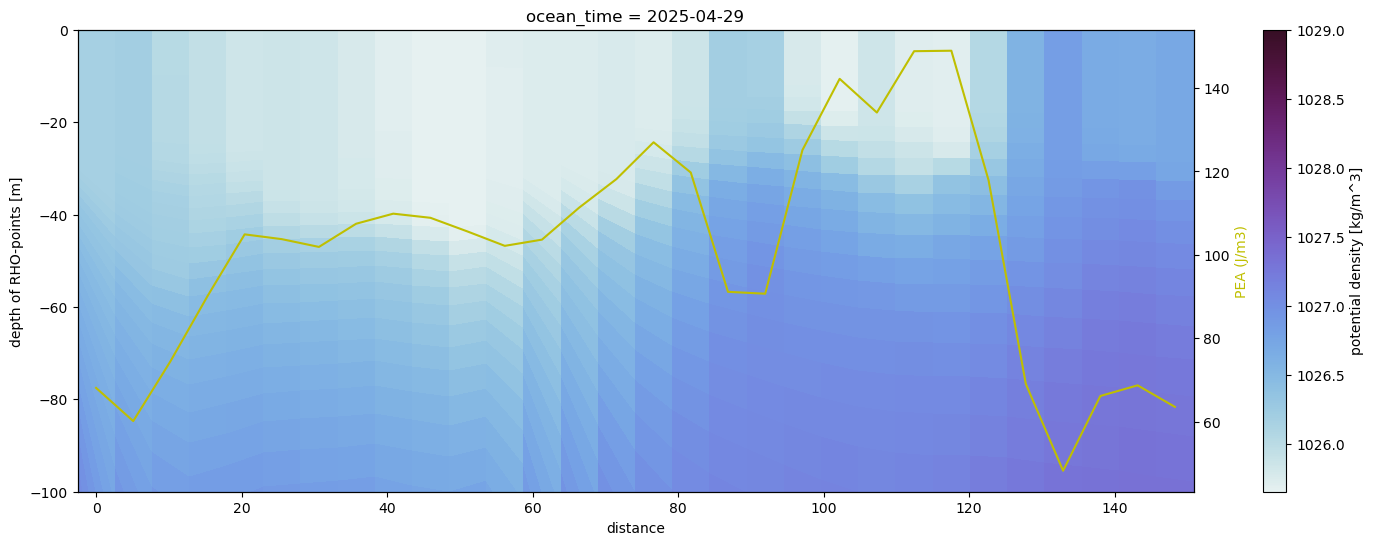

In [43]:
fig, ax1 = plt.subplots(figsize=(18,6))
ax2 = ax1.twinx()

dens.plot.pcolormesh('distance', 'z_rho', ylim=(-100,0), vmax=1029, cmap=cmocean.cm.dense, ax=ax1)
ax2.plot(dens.distance.values, PEA, c='y')
ax2.set_ylabel('PEA (J/m3)', color='y')


In the figure above, you see that the PEA increases where the water column is more stratified, and decreases where it is more mixed. 

## Create the adjoint sensitivity forcing files:

In [7]:

def PEA_forcing(file, maxdepth ):
    """
    Calculate the potential energy anomaly forcing file for impact runs
    """
    # Coordinates of the points we are interested in: 
    lats = np.array( [62.367, 62.39951724, 62.43203448, 62.46455172, 62.49706897, 62.52958621, 62.56210345, 62.59462069, 62.62713793, 62.65965517 ,62.69217241 ,62.72468966 ,62.7572069, 62.78972414, 62.82224138, 62.85475862, 62.88727586, 62.9197931, 62.95231034, 62.98482759, 63.01734483, 63.04986207, 63.08237931, 63.11489655, 63.14741379, 63.17993103, 63.21244828, 63.24496552, 63.27748276, 63.31])
    lons = np.array([5.2, 5.13101715, 5.06203429, 4.99305144, 4.92344291, 4.85403065, 4.78450732, 4.71461734, 4.64453494, 4.57431438, 4.50364706, 4.43342937, 4.36277103, 4.2916826, 4.22068756, 4.14938761, 4.07809246, 4.00632379, 3.93487649, 3.8628644, 3.79040918, 3.71786269, 3.6453162, 3.57276972, 3.50018664, 3.42703098, 3.35387186, 3.28024791, 3.20663875, 3.13301153])

    # Constants (linear equation of state). These are calculated for the specific cycle, so this is an example:
    a = 0.00014225507684357882  # Alpha 
    b = 0.0007651779291776442  # Beta
    T0 = 7.822496971006817  # T0
    S0 = 33.64101118358283  # S0
    R0 = 1026.2304203640072 # Density

    Ginp = roppy.SGrid(Dataset(file))

    with xr.open_dataset(file) as ds:
        dtfac = ds.nHIS.values/ds.ntimes.values

        # Construct output matrices:
        ad_temp = np.zeros_like(ds.temp.values)
        ad_salt = np.zeros_like(ds.salt.values)

        temp_section1 = interpolator(Ginp, ds.isel(ocean_time = 0), 'temp', lons, lats, ad_F=None)
        dis = temp_section1['dis'][0,-1] * 1000
        ad_ind = 9.81 / (maxdepth*dis)
        ind = 0
        # Loop over ocean_time steps:
        for n in range(len(ds.ocean_time.values)):
     
            if n == 0 or n == len(ds.ocean_time.values) -1:
                dt = 0.5* dtfac
            else:
                dt = dtfac
            print(n, ds.ocean_time.values[n], dt )

            ad_temp_n = np.zeros([ad_temp.shape[1], ad_temp.shape[2], ad_temp.shape[3]])
            ad_salt_n = np.zeros([ad_salt.shape[1], ad_salt.shape[2], ad_salt.shape[3]])

            temp_section = interpolator(Ginp, ds.isel(ocean_time = n), 'temp', lons, lats, ad_F=None)

            ad_ind_temporary = np.zeros_like(temp_section['val'])

            Km, Im = ad_ind_temporary.shape

            # Set all densities deeper than maxdepth  to zero
            mask = np.ones_like(temp_section['val'])
            mask[np.where( (temp_section['z_r'] - temp_section['dz']/2) < -1*maxdepth)] = 0

            for k in range(Km):
                    ad_ind_temporary[k, :] = ad_ind_temporary[k, :] + ad_ind

            # Set all values where mask = 0 to be 0 (simply multiply with mask as mask is either 1 or zero...). 
            ad_ind_temporary *= mask 
            ad_dens = -1* ad_ind_temporary * temp_section['z_r']*temp_section['dz']*temp_section['dislen']*1000 * dt

            ad_temp_array = -1* R0 * a * ad_dens
            ad_salt_array =  R0 * b * ad_dens

            # ADJOINT of interpolation here! 
            ad_temp_section = interpolator(Ginp, ds.isel(ocean_time = n), ad_temp_n, lons, lats, ad_F=ad_temp_array, mode = 'ad')
            ad_salt_section = interpolator(Ginp, ds.isel(ocean_time = n), ad_salt_n, lons, lats, ad_F=ad_salt_array, mode = 'ad')
            ad_temp[n, :, :, : ] = ad_temp_section['field']
            ad_salt[n, :, :, : ] = ad_salt_section['field']

        return ad_temp, ad_salt

In [8]:
maxdepth = 98 # Maximum depth for PEA calculation
fwdfile = 'https://thredds.met.no/thredds/dodsC/foccus/norshelf-ana_fwd_20250501T00Z_outer0.nc'
ad_temp, ad_salt = PEA_forcing(fwdfile, maxdepth)

0 2025-04-29T00:00:00.000000000 0.03125
1 2025-04-29T03:00:00.000000000 0.0625
2 2025-04-29T06:00:00.000000000 0.0625
3 2025-04-29T09:00:00.000000000 0.0625
4 2025-04-29T12:00:00.000000000 0.0625
5 2025-04-29T15:00:00.000000000 0.0625
6 2025-04-29T18:00:00.000000000 0.0625
7 2025-04-29T21:00:00.000000000 0.0625
8 2025-04-30T00:00:00.000000000 0.0625
9 2025-04-30T03:00:00.000000000 0.0625
10 2025-04-30T06:00:00.000000000 0.0625
11 2025-04-30T09:00:00.000000000 0.0625
12 2025-04-30T12:00:00.000000000 0.0625
13 2025-04-30T15:00:00.000000000 0.0625
14 2025-04-30T18:00:00.000000000 0.0625
15 2025-04-30T21:00:00.000000000 0.0625
16 2025-05-01T00:00:00.000000000 0.03125


### Plotting the result:

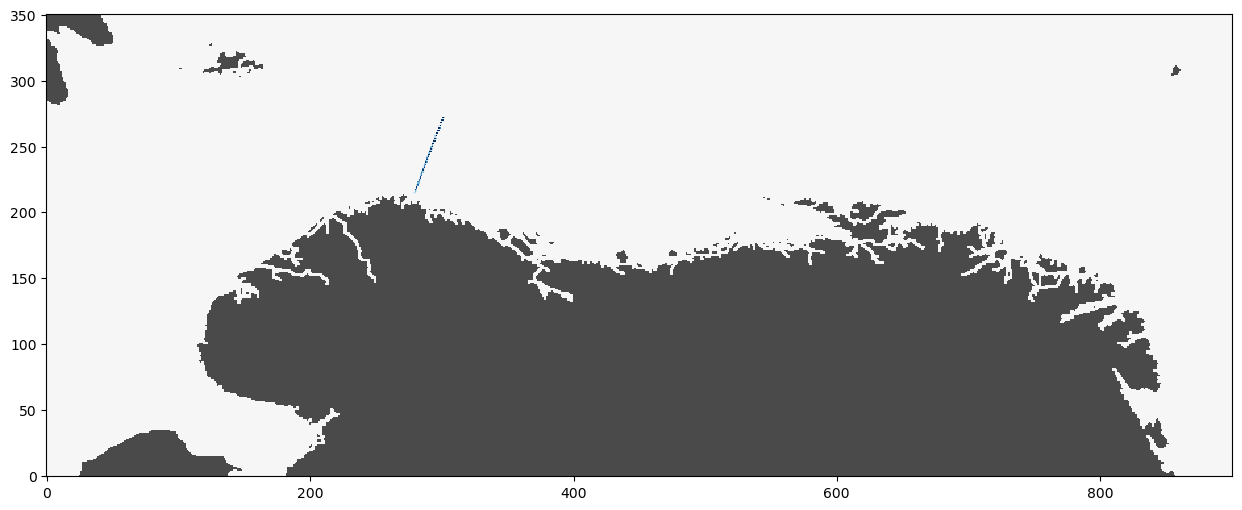

In [42]:
fig, ax = plt.subplots(figsize=(18,6))
mask[mask == 1] = np.nan
plt.imshow(ad_temp[-1,-1, :, :], cmap='RdBu_r', vmin=-1e-5, vmax=1e-5, interpolation='none')
plt.imshow(mask, cmap='Greys_r', interpolation='none', alpha=0.7)
plt.gca().invert_yaxis()


### These arrays need to be stored in a file that serves as input while running the ROMS impact simulation. Below is an example of how this can be performed:

In [48]:
# Directory to store the adjoint forcing:
outputDir = '/path/to/output/dir/'

In [ ]:
# We need to run this to create the file that we will write the adjoint data to
adsfile = create_adsenfile(fwdfile, outputDir)

with xr.open_dataset(fwdfile) as dsgrid:
    mask = dsgrid.mask_rho.values

# Extend mask to same dimensions as ad_temp/ad_salt
mask = np.broadcast_to(mask, (ad_temp.shape[0], ad_temp.shape[1],) + mask.shape)

# Use 4D mask to set entries where mask == 0 to NaN
ad_temp = np.where(mask == 0, np.nan, ad_temp)
ad_salt = np.where(mask == 0, np.nan, ad_salt)

ad_temp = np.ma.masked_invalid(ad_temp)
ad_salt = np.ma.masked_invalid(ad_salt)

with Dataset(adsfile, 'r+') as ds:
    np.ma.set_fill_value(ad_temp, ds.variables['v'][0,:].fill_value)
    np.ma.set_fill_value(ad_salt, ds.variables['v'][0,:].fill_value)

    ds.variables['temp'][:] = ad_temp
    ds.variables['salt'][:] = ad_salt

print('Done with {}'.format(adsfile))
command = 'ncks -7 -L 1 --ppc default=3#temp=8#salt=8  {} {}'.format(adsfile, adsfile.replace('_ads_', '_tmpads_'))
subprocess.call(command, shell = True)
command = 'mv {} {}'.format(adsfile.replace('_ads_', '_tmpads_'), adsfile)
subprocess.call(command, shell = True)